In [1]:
#uploading dataset
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading dataset
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
#dropping useless columns
df = df.drop("CustomerID", axis=1)

In [5]:
#encoding converting text to numbers
df["Genre"] = df["Genre"].map({"Male": 0, "Female": 1})

In [6]:
#checking data
df.head()

,Genre,Age,Annual_Income_(k$),Spending_Score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [7]:
#choosing features for clusters
X = df[["Age", "Annual_Income_(k$)", "Spending_Score"]]

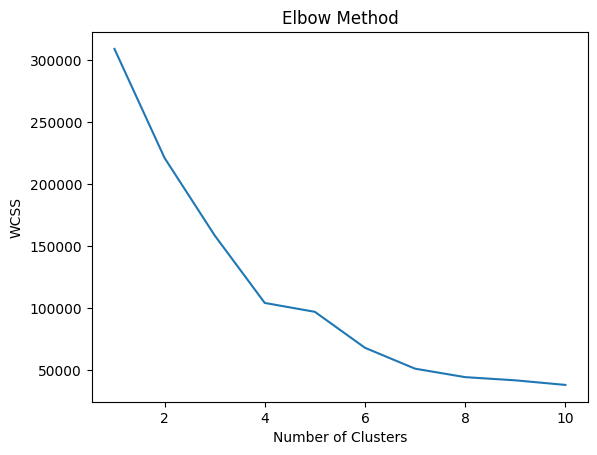

In [8]:
#finding best no. of clusters
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
#applying k means
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

df["Cluster"] = y_kmeans
df.head()

,Genre,Age,Annual_Income_(k$),Spending_Score,Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,0
3,1,23,16,77,2
4,1,31,17,40,0


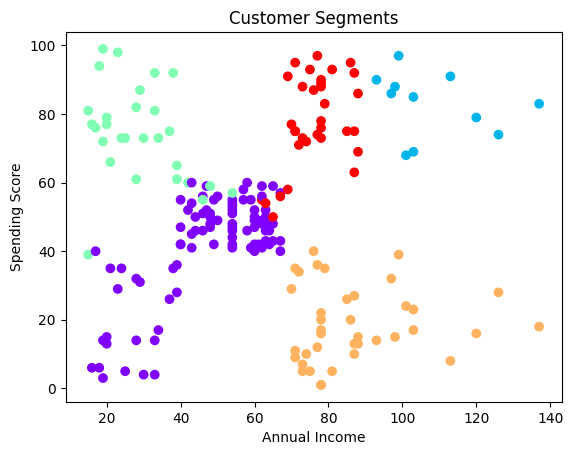

In [11]:
#visualizing clusters 2d view
plt.scatter(X.iloc[:,1], X.iloc[:,2], c=y_kmeans, cmap="rainbow")
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [12]:
#cluster centers
kmeans.cluster_centers_

array([[ 46.21348315,  47.71910112,  41.79775281],
       [ 32.45454545, 108.18181818,  82.72727273],
       [ 24.68965517,  29.5862069 ,  73.65517241],
       [ 40.39473684,  87.        ,  18.63157895],
       [ 31.78787879,  76.09090909,  77.75757576]])